# Lab 6B: Gradient Descent for Linear Regression

**Course:** Machine Learning Lab  
**Topic:** Gradient Descent optimization  
**Dataset:** Synthetic Ohm's Law current-voltage data

## Lab Objective
The objective of this lab is to understand how gradient descent learns the parameters of a linear regression model by repeatedly reducing prediction error.


## 1. Import Libraries and Generate Data
This code imports the required libraries and creates a synthetic voltage-current dataset. The generated data follows Ohm's Law with added noise, which helps simulate real experimental measurements.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ── 1. Data Generation ───────────────────────────────────────────────────────
np.random.seed(42)                        # reproducible results
R_true = 1000                             # Ω

I_flat = np.linspace(0, 0.01, 50)        # 0 to 10 mA in Amperes
V_clean = R_true * I_flat                 # 0 to 10 V
noise   = np.random.normal(0, 0.05, size=I_flat.shape)  # noise std 0.05 V (was 0.2!)
V_noisy = V_clean + noise

## 2. Normalize the Data
Normalization converts the current and voltage values to a common scale. This helps gradient descent converge more smoothly because the features and target values are centered and scaled.


In [2]:
# ── 3. Normalize for Gradient Descent ────────────────────────────────────────
I_mean, I_std = I_flat.mean(), I_flat.std()
V_mean, V_std = V_noisy.mean(), V_noisy.std()

I_norm = (I_flat - I_mean) / I_std
V_norm = (V_noisy - V_mean) / V_std

## 3. Apply Gradient Descent
The following cell initializes model parameters, calculates predictions and errors, computes gradients, and updates the slope and intercept over multiple epochs. The loss history records how the error changes during training.


Converged at epoch 136

GD slope     : 997.10 Ω  (expected 1000)
GD intercept : 0.0034 V  (expected ~0)


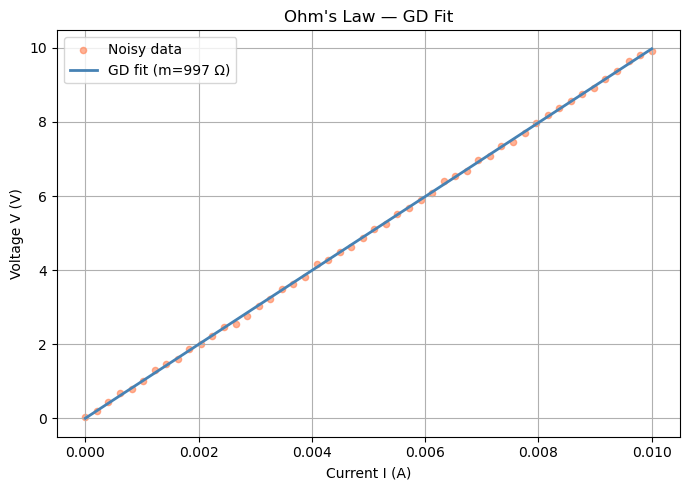

In [3]:
# ── 4. Gradient Descent ───────────────────────────────────────────────────────
alpha = 0.05
m, b  = 1.0, 100.0
loss_history = []

for epoch in range(500):
    V_pred = m * I_norm + b
    error  = V_pred - V_norm

    loss = (error ** 2).mean()
    loss_history.append(float(loss))

    dm = 2 * (I_norm * error).mean()
    db = 2 * error.mean()

    m -= alpha * dm
    b -= alpha * db

    if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < 1e-9:
        print(f"Converged at epoch {epoch}")
        break

# ── 5. Rescale back to physical units ────────────────────────────────────────
m_phys = m * (V_std / I_std)
b_phys = b * V_std + V_mean - m_phys * I_mean

print(f"\nGD slope     : {m_phys:.2f} Ω  (expected 1000)")
print(f"GD intercept : {b_phys:.4f} V  (expected ~0)")

# ── 6. Plots ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(I_flat, V_noisy, s=20, alpha=0.6, color="coral", label="Noisy data")
ax.plot(I_flat, m_phys * I_flat + b_phys,
        color="steelblue", linewidth=2, label=f"GD fit (m={m_phys:.0f} Ω)")
ax.set_xlabel("Current I (A)")
ax.set_ylabel("Voltage V (V)")
ax.set_title("Ohm's Law — GD Fit")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## Mathematical Explanation
The formulas below show how prediction, error, loss, and gradients are calculated during gradient descent. These equations explain the logic used in the previous code cell.


## Gradient Descent — Mathematical Formulation

**Prediction:**

$$\hat{V}_i = m \cdot I_i^{norm} + b$$

**Error:**

$$e_i = \hat{V}_i - V_i^{norm}$$

**Loss Function (Mean Squared Error):**

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} e_i^2$$

**Gradients:**

$$\frac{\partial \mathcal{L}}{\partial m} = \frac{2}{N} \sum_{i=1}^{N} I_i^{norm} \cdot e_i$$

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{2}{N} \sum_{i=1}^{N} e_i$$

**Parameter Update:**

$$m \leftarrow m - \alpha \cdot \frac{\partial \mathcal{L}}{\partial m}$$

$$b \leftarrow b - \alpha \cdot \frac{\partial \mathcal{L}}{\partial b}$$

where $\alpha$ is the **learning rate**.

## Rescaling and Physical Interpretation
Because the model is trained on normalized values, the learned parameters must be converted back to physical units. After rescaling, the slope can again be interpreted as resistance in ohms.


## Rescaling Back to Physical Units

When we normalize:

$$I_{norm} = \frac{I - \mu_I}{\sigma_I} \qquad V_{norm} = \frac{V - \mu_V}{\sigma_V}$$

GD learns in normalized space:

$$V_{norm} = m \cdot I_{norm} + b$$


## Substituting Back

Replace $I_{norm}$ and $V_{norm}$ with their definitions:

$$\frac{V - \mu_V}{\sigma_V} = m \cdot \frac{I - \mu_I}{\sigma_I} + b$$

Multiply both sides by $\sigma_V$:

$$V - \mu_V = m \cdot \frac{\sigma_V}{\sigma_I} \cdot (I - \mu_I) + b \cdot \sigma_V$$

Expand the right side:

$$V - \mu_V = m \cdot \frac{\sigma_V}{\sigma_I} \cdot I \;\;-\;\; m \cdot \frac{\sigma_V}{\sigma_I} \cdot \mu_I + b \cdot \sigma_V$$

Move $\mu_V$ to the right:

$$V = \underbrace{m \cdot \frac{\sigma_V}{\sigma_I}}_{\texttt{m\_phys}} \cdot I \;\;+\;\; \underbrace{b \cdot \sigma_V + \mu_V - m \cdot \frac{\sigma_V}{\sigma_I} \cdot \mu_I}_{\texttt{b\_phys}}$$

Therefore:

$$\boxed{m_{phys} = m \times \frac{\sigma_V}{\sigma_I}}$$

$$\boxed{b_{phys} = b \times \sigma_V + \mu_V - m_{phys} \times \mu_I}$$

## Clearly Labeled Results
The expected result is a decreasing loss curve and a final slope that represents the estimated resistance. If the loss decreases over epochs, gradient descent is successfully minimizing the prediction error.


## Conclusion
Gradient descent provides an iterative way to learn linear regression parameters. Normalization improves the optimization process, and rescaling allows the final model to be interpreted using the original current and voltage units.
